# Prediksi Pembangkitan Energi Surya Berbasis Panel Fotovoltaik
**Pembelajaran Mesin — S1 Sains Data, UNESA**

Dataset: solarPV.csv — data historis pembangkitan energi surya per jam dari 179+ wilayah di Eropa, Afrika Utara, dan Timur Tengah (sumber: DTU Data / PVGIS).

Alur notebook ini mengikuti pipeline machine learning standar:
1. Load Data
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Feature Engineering
5. Pelatihan Model (Random Forest, XGBoost, LSTM)
6. Evaluasi dan Perbandingan Model
7. Scaling ke Seluruh Wilayah
8. Deteksi Anomali
9. Multi-Step Forecasting
10. Export Hasil

## 1. Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/solarPV.csv', on_bad_lines='skip')

print("Shape:", df.shape)
print("\nSample kolom wilayah:", df.columns.tolist()[1:6])
df.head()

Shape: (12373, 180)

Sample kolom wilayah: ['AL00', 'AT00', 'AT01', 'AT02', 'AT03']


,Time,AL00,AT00,AT01,AT02,AT03,BA00,BE00,BE01,BE02,...,UA01,UA02,UK00,UK01,UK02,UK03,UK04,UK05,UKNI,XK00
0,01-Jan-1982 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,01-Jan-1982 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,01-Jan-1982 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,01-Jan-1982 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,01-Jan-1982 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Exploratory Data Analysis (EDA)

Sebelum membersihkan data, kita perlu memahami struktur dan pola dasar dataset.

In [ ]:
# Konversi kolom Time ke datetime dan jadikan index
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df = df.dropna(subset=['Time'])
df.set_index('Time', inplace=True)

print("Rentang waktu :", df.index.min(), "hingga", df.index.max())
print("Jumlah baris  :", len(df))
print("Jumlah wilayah:", df.shape[1])

Rentang waktu : 1982-01-01 00:00:00 hingga 1983-05-31 12:00:00
Jumlah baris  : 12373
Jumlah wilayah: 179


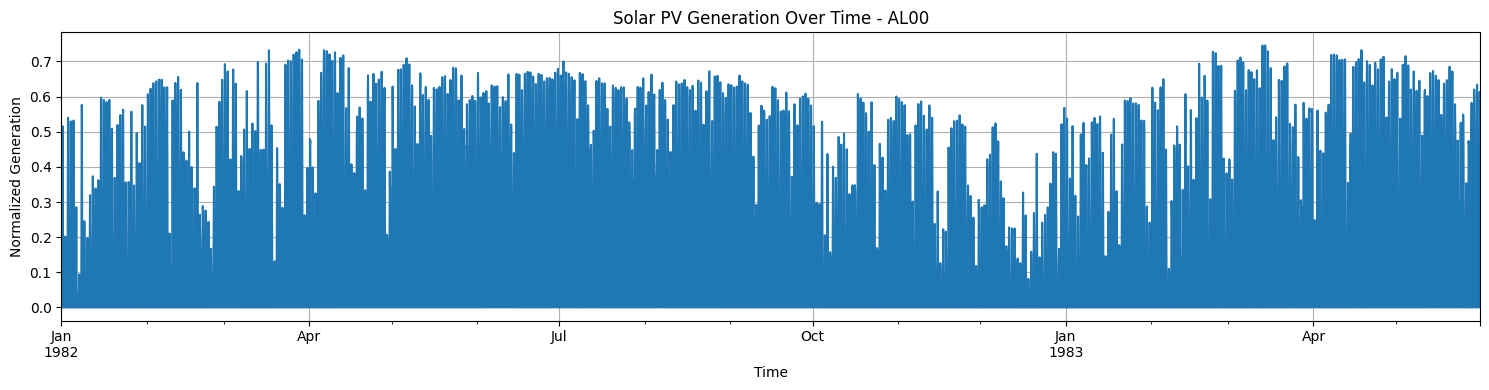

In [ ]:
# Tren deret waktu - AL00 (Albania) sebagai contoh
plt.figure(figsize=(15, 4))
df['AL00'].plot()
plt.title('Solar PV Generation Over Time - AL00')
plt.ylabel('Normalized Generation')
plt.xlabel('Time')
plt.grid(True)
plt.tight_layout()
plt.show()

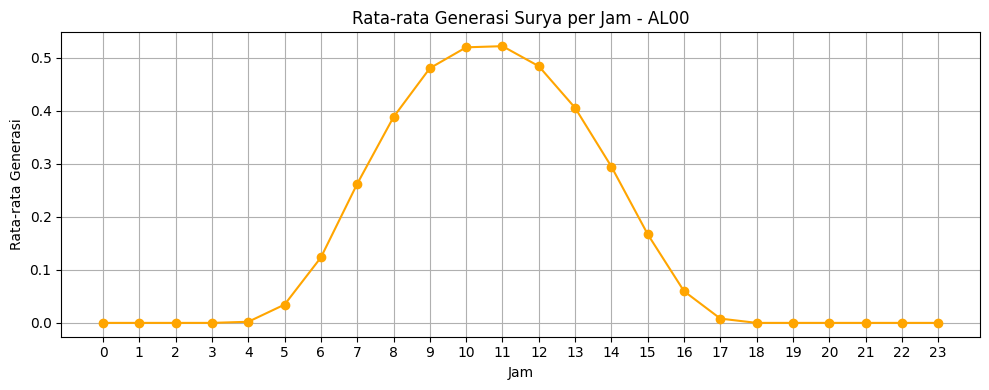

In [ ]:
# Pola harian: rata-rata generasi per jam
temp = df[['AL00']].copy()
temp['hour'] = temp.index.hour
hourly_avg = temp.groupby('hour')['AL00'].mean()

plt.figure(figsize=(10, 4))
hourly_avg.plot(marker='o', color='orange')
plt.title('Rata-rata Generasi Surya per Jam - AL00')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Generasi')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

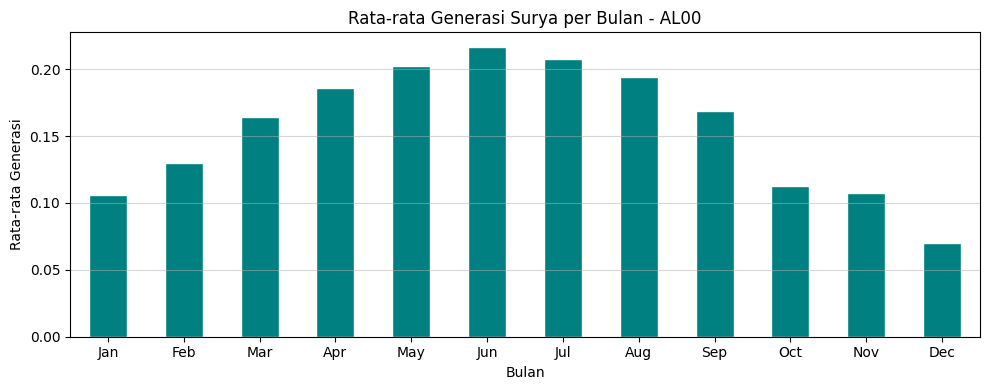

In [ ]:
# Pola musiman: rata-rata generasi per bulan
temp['month'] = temp.index.month
monthly_avg = temp.groupby('month')['AL00'].mean()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(10, 4))
monthly_avg.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Rata-rata Generasi Surya per Bulan - AL00')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Generasi')
plt.xticks(range(12), month_labels, rotation=0)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Cek missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("Top 10 kolom dengan missing values:")
print(missing.head(10))
print(f"\nTotal sel kosong: {df.isnull().sum().sum()}")

Top 10 kolom dengan missing values:
UK05    1
UKNI    1
XK00    1
TR11    1
TR12    1
TR13    1
TR14    1
TR15    1
UA00    1
UA01    1
dtype: int64

Total sel kosong: 16


## 3. Data Cleaning

Missing values diisi dengan 0, yang secara domain berarti tidak ada produksi energi pada periode tersebut.

In [ ]:
df_clean = df.fillna(0)

print("Missing values setelah cleaning:", df_clean.isnull().sum().sum())
print("Shape setelah cleaning         :", df_clean.shape)

Missing values setelah cleaning: 0
Shape setelah cleaning         : (12373, 179)


## 4. Feature Engineering

Fitur temporal diekstraksi dari indeks datetime. Lag feature (lag_1) — nilai generasi 1 jam sebelumnya — ditambahkan pada tahap modeling untuk menangkap dependensi autoregresif.

In [ ]:
df_clean['hour']        = df_clean.index.hour
df_clean['day']         = df_clean.index.day
df_clean['month']       = df_clean.index.month
df_clean['day_of_week'] = df_clean.index.dayofweek

base_features = ['hour', 'day', 'month', 'day_of_week']

print("Fitur temporal berhasil dibuat:", base_features)
print("Shape dataset                 :", df_clean.shape)

Fitur temporal berhasil dibuat: ['hour', 'day', 'month', 'day_of_week']
Shape dataset                 : (12373, 183)


## 5. Pelatihan Model

Tiga model dilatih secara bertahap. Split temporal 80:20 tanpa shuffle digunakan untuk menjaga urutan waktu.

### 5.1 Random Forest (Baseline)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

target = 'AL00'
features = base_features

X = df_clean[features]
y = pd.to_numeric(df_clean[target], errors='coerce').fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print(f"Random Forest  ->  MSE: {mse_rf:.4f}  |  R2: {r2_rf:.4f}")

Random Forest  ->  MSE: 0.0092  |  R2: 0.8406


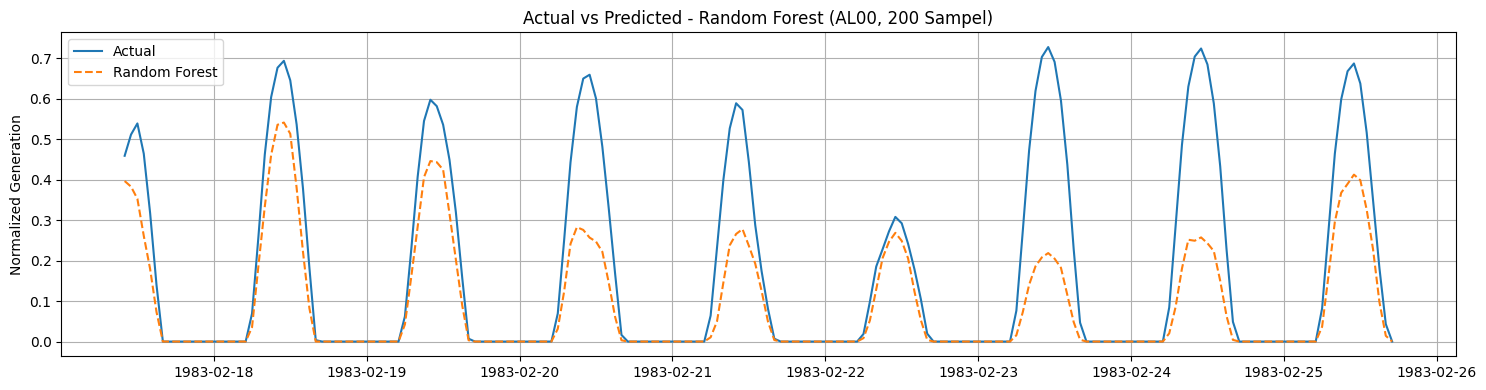

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(15, 4))
plt.plot(y_test.index[:200], y_test.values[:200], label='Actual')
plt.plot(y_test.index[:200], y_pred_rf[:200], label='Random Forest', linestyle='--')
plt.title('Actual vs Predicted - Random Forest (AL00, 200 Sampel)')
plt.ylabel('Normalized Generation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

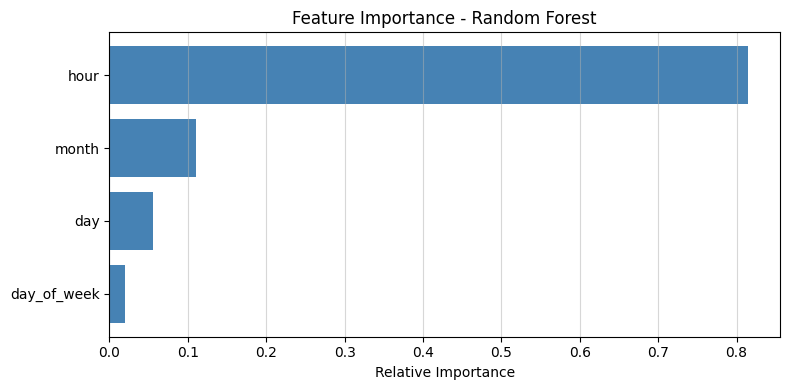

In [ ]:
# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 4))
plt.barh(range(len(indices)), importances[indices], color='steelblue')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Feature Importance - Random Forest')
plt.xlabel('Relative Importance')
plt.grid(axis='x', alpha=0.5)
plt.tight_layout()
plt.show()

### 5.2 XGBoost

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb  = r2_score(y_test, y_pred_xgb)

print(f"XGBoost  ->  MSE: {mse_xgb:.4f}  |  R2: {r2_xgb:.4f}")

XGBoost  ->  MSE: 0.0059  |  R2: 0.8980


### 5.3 Hyperparameter Tuning XGBoost

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10, scoring='r2', cv=3, verbose=0, random_state=42
)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best R2 (CV)   :", round(random_search.best_score_, 4))

Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best R2 (CV)   : 0.8524


### 5.4 XGBoost dengan Lag Feature

In [ ]:
def train_lag_model(region_name, df_clean, base_features):
    data = df_clean[[region_name] + base_features].copy()
    data[region_name] = pd.to_numeric(data[region_name], errors='coerce').fillna(0)

    # Clipping outlier ekstrem pada persentil ke-99
    upper = data[region_name].quantile(0.99)
    if upper > 0:
        data[region_name] = data[region_name].clip(upper=upper * 1.5)

    # Lag feature: nilai generasi 1 jam sebelumnya
    data['lag_1'] = data[region_name].shift(1).fillna(0)

    # Filter jam siang untuk fokus pada periode produksi aktif (06.00-20.00)
    data = data[(data['hour'] >= 6) & (data['hour'] <= 20)]

    model_features = base_features + ['lag_1']
    X = data[model_features]
    y = data[region_name]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )

    model = xgb.XGBRegressor(
        n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42
    )
    model.fit(X_tr, y_tr)

    preds = model.predict(X_te)
    return {
        'Region': region_name,
        'MSE': mean_squared_error(y_te, preds),
        'R2': r2_score(y_te, preds),
        'model': model,
        'X_test': X_te,
        'y_test': y_te
    }

result_al00 = train_lag_model('AL00', df_clean, base_features)
print(f"XGBoost + Lag (AL00)  ->  MSE: {result_al00['MSE']:.4f}  |  R2: {result_al00['R2']:.4f}")

XGBoost + Lag (AL00)  ->  MSE: 0.0005  |  R2: 0.9910


### 5.5 LSTM (Deep Learning)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

target_region = 'AL00'
target_data = pd.to_numeric(df_clean[target_region], errors='coerce').fillna(0).values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(target_data)

def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(scaled_data)
train_size = int(len(X_seq) * 0.8)

X_train_lstm = X_seq[:train_size]
X_test_lstm  = X_seq[train_size:]
y_train_lstm = y_seq[:train_size]
y_test_lstm  = y_seq[train_size:]

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(24, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
print("Melatih LSTM...")
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20, batch_size=64,
    validation_split=0.1, verbose=1
)

Melatih LSTM...
Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0308 - val_loss: 0.0112
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 0.0098 - val_loss: 0.0098
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0078 - val_loss: 0.0072
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0065 - val_loss: 0.0059
Epoch 5/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0056 - val_loss: 0.0054
Epoch 6/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0047 - val_loss: 0.0047
Epoch 7/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0044 - val_loss: 0.0035
Epoch 8/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0039 - val_loss: 0.0030
Epoch 9/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0035 - val_loss: 0.0025
Epoch 10/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0032 - val_loss: 0.0026
Epoch 11/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0030 - val_loss: 0.0020
Epoch 12/20
139/139 ━━━━━

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
LSTM  ->  MSE: 0.0009  |  R2: 0.9911


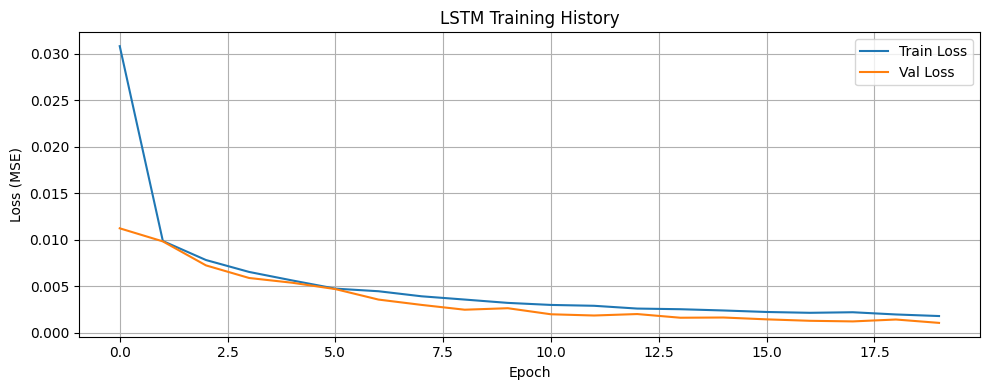

In [ ]:
# Evaluasi LSTM
lstm_preds = lstm_model.predict(X_test_lstm)
lstm_mse   = mean_squared_error(y_test_lstm, lstm_preds)
lstm_r2    = r2_score(y_test_lstm, lstm_preds)

print(f"LSTM  ->  MSE: {lstm_mse:.4f}  |  R2: {lstm_r2:.4f}")

# Training History
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Evaluasi dan Perbandingan Model

Perbandingan Performa Model (AL00):


,Model,MSE,R2 Score
0,Random Forest,0.009173,0.840609
1,XGBoost,0.005868,0.898033
2,XGBoost + Lag,0.000545,0.990977
3,LSTM,0.000924,0.991068


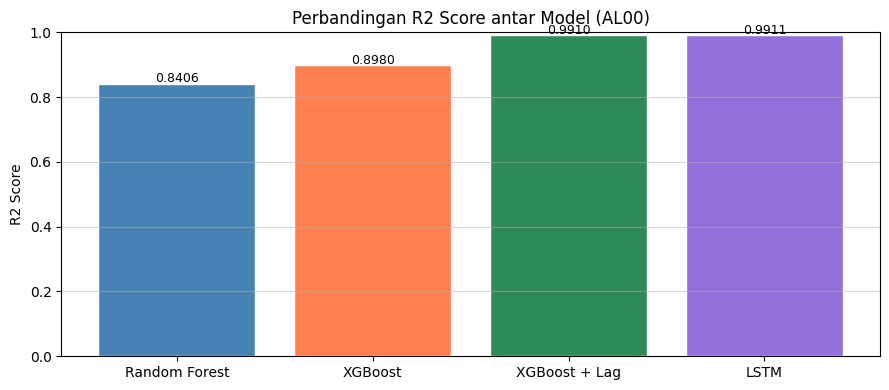

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'XGBoost + Lag', 'LSTM'],
    'MSE':      [mse_rf, mse_xgb, result_al00['MSE'], lstm_mse],
    'R2 Score': [r2_rf,  r2_xgb,  result_al00['R2'],  lstm_r2]
})

print("Perbandingan Performa Model (AL00):")
display(comparison_df)

colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
plt.figure(figsize=(9, 4))
bars = plt.bar(comparison_df['Model'], comparison_df['R2 Score'], color=colors, edgecolor='white')
for bar, val in zip(bars, comparison_df['R2 Score']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.4f}", ha='center', fontsize=9)
plt.title('Perbandingan R2 Score antar Model (AL00)')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Scaling Model ke Seluruh Wilayah

Model XGBoost + Lag diaplikasikan ke semua 179+ wilayah secara otomatis.

In [ ]:
import time

exclude_cols = ['hour', 'day', 'month', 'day_of_week']
regions_to_process = [col for col in df_clean.columns if col not in exclude_cols]

all_results = []
start = time.time()

print(f"Memproses {len(regions_to_process)} wilayah...")
for i, region in enumerate(regions_to_process):
    try:
        res = train_lag_model(region, df_clean, base_features)
        all_results.append({'Region': res['Region'], 'MSE': res['MSE'], 'R2': res['R2']})
        if (i + 1) % 40 == 0:
            print(f"  Selesai: {i+1}/{len(regions_to_process)}")
    except Exception:
        continue

final_df = pd.DataFrame(all_results)
print(f"\nSelesai dalam {(time.time()-start)/60:.1f} menit.")
print("\nRingkasan R2 Score:")
display(final_df['R2'].describe())

Memproses 179 wilayah...
  Selesai: 40/179
  Selesai: 80/179
  Selesai: 120/179
  Selesai: 160/179

Selesai dalam 0.9 menit.

Ringkasan R2 Score:


,R2
count,179.000000
mean,0.985107
std,0.010059
min,0.951582
25%,0.978947
50%,0.987704
75%,0.992544
max,0.999483


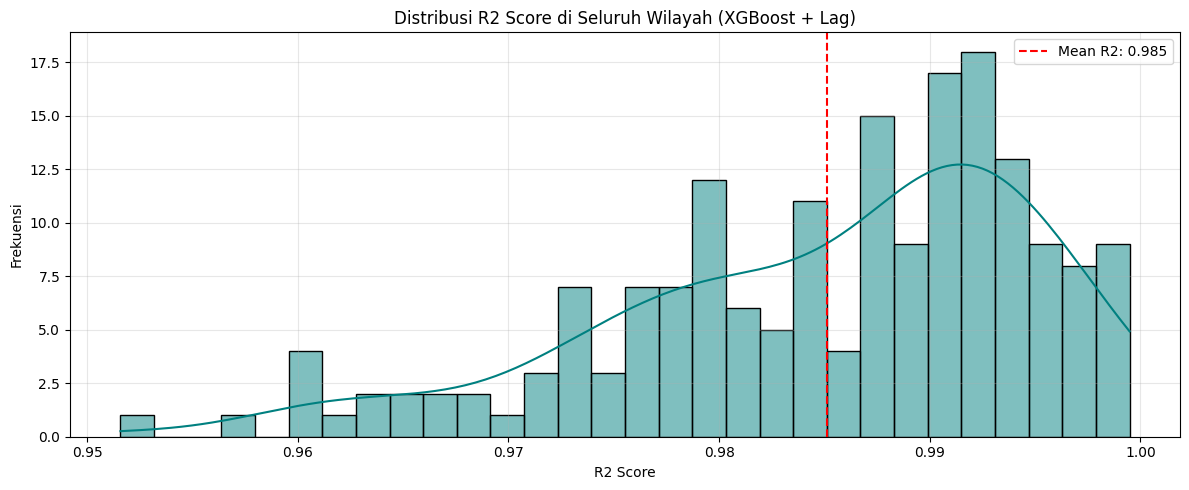

Top 5 Wilayah:


,Region,MSE,R2
93,LY00,0.000047,0.999483
34,EG00,0.000062,0.999395
32,DZ03,0.000065,0.999234
96,LY03,0.000072,0.999215
95,LY02,0.000080,0.999179



Bottom 5 Wilayah:


,Region,MSE,R2
91,LU00,0.002054,0.951582
110,NL02,0.001657,0.957588
8,BE02,0.001655,0.960044
111,NL03,0.000958,0.960522
7,BE01,0.001702,0.960530


In [ ]:
# Distribusi R2 Score seluruh wilayah
plt.figure(figsize=(12, 5))
sns.histplot(final_df['R2'], bins=30, kde=True, color='teal')
plt.axvline(final_df['R2'].mean(), color='red', linestyle='--',
            label=f"Mean R2: {final_df['R2'].mean():.3f}")
plt.title('Distribusi R2 Score di Seluruh Wilayah (XGBoost + Lag)')
plt.xlabel('R2 Score')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 Wilayah:")
display(final_df.sort_values('R2', ascending=False).head())

print("\nBottom 5 Wilayah:")
display(final_df.sort_values('R2').head())

## 8. Deteksi Anomali dengan Isolation Forest

Isolation Forest mendeteksi pola pembangkitan yang menyimpang dari pola normal, berguna untuk mengidentifikasi gangguan peralatan atau cuaca ekstrem.

In [ ]:
from sklearn.ensemble import IsolationForest

data_anomaly = df_clean[['AL00', 'hour', 'month']].copy()
data_anomaly['AL00'] = pd.to_numeric(data_anomaly['AL00'], errors='coerce').fillna(0)

iso_forest = IsolationForest(contamination=0.01, random_state=42)
data_anomaly['anomaly'] = iso_forest.fit_predict(
    data_anomaly[['AL00', 'hour', 'month']]
)

anomalies = data_anomaly[data_anomaly['anomaly'] == -1]
print(f"Anomali terdeteksi: {len(anomalies)} dari {len(data_anomaly)} titik data "
      f"({len(anomalies)/len(data_anomaly)*100:.1f}%)")

Anomali terdeteksi: 124 dari 12373 titik data (1.0%)


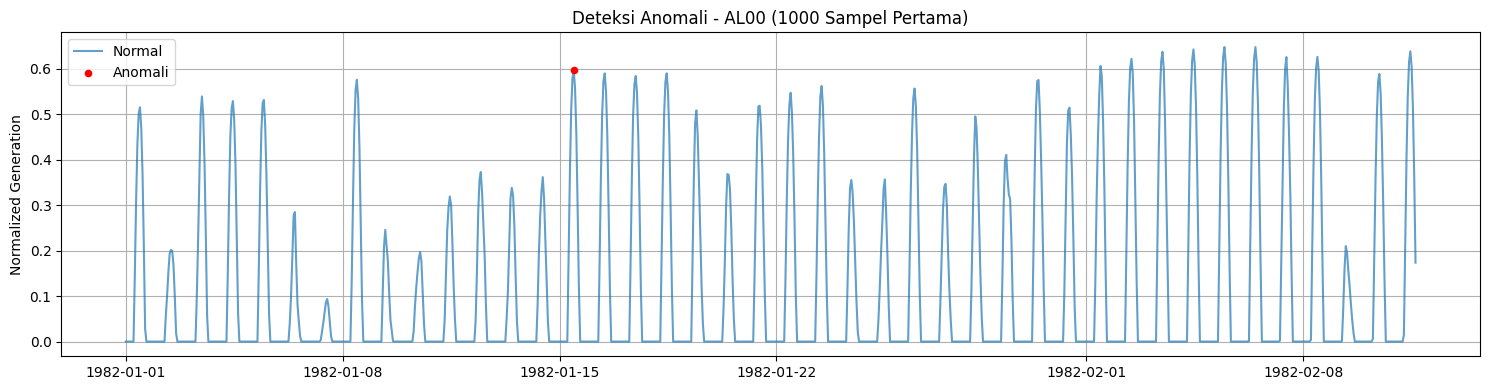

In [ ]:
# Visualisasi anomali pada deret waktu
plt.figure(figsize=(15, 4))
plt.plot(data_anomaly.index[:1000], data_anomaly['AL00'][:1000], alpha=0.7, label='Normal')
anom_in_range = anomalies[anomalies.index.isin(data_anomaly.index[:1000])]
plt.scatter(anom_in_range.index, anom_in_range['AL00'],
            color='red', label='Anomali', zorder=5, s=20)
plt.title('Deteksi Anomali - AL00 (1000 Sampel Pertama)')
plt.ylabel('Normalized Generation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

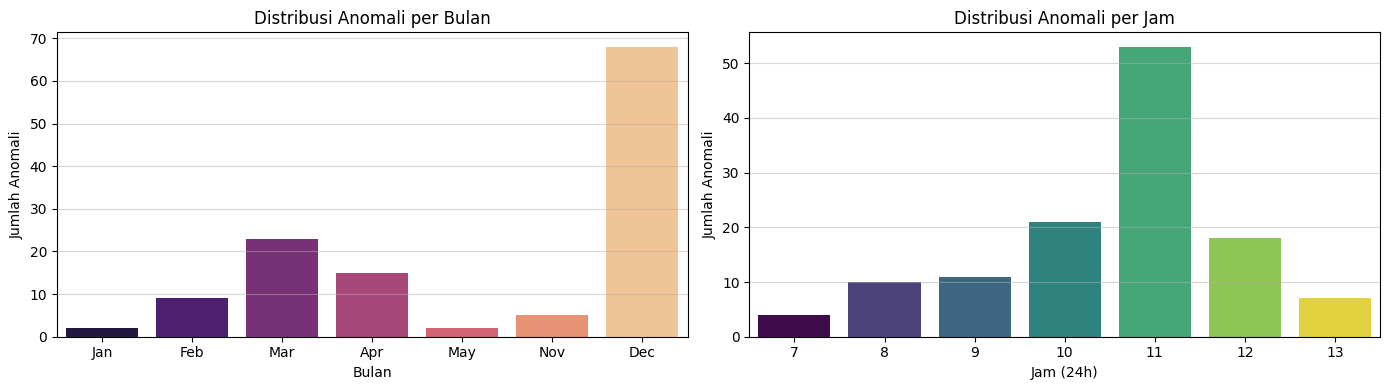

In [ ]:
# Distribusi anomali per bulan
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

anomaly_by_month = anomalies.groupby('month').size().reset_index(name='count')
anomaly_by_month['month_name'] = anomaly_by_month['month'].map(month_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(x='month_name', y='count', data=anomaly_by_month,
            hue='month_name', palette='magma', legend=False, ax=axes[0])
axes[0].set_title('Distribusi Anomali per Bulan')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Jumlah Anomali')
axes[0].grid(axis='y', alpha=0.5)

anomaly_by_hour = anomalies.groupby('hour').size().reset_index(name='count')
sns.barplot(x='hour', y='count', data=anomaly_by_hour,
            hue='hour', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Distribusi Anomali per Jam')
axes[1].set_xlabel('Jam (24h)')
axes[1].set_ylabel('Jumlah Anomali')
axes[1].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

## 9. Multi-Step Recursive Forecasting

Model memprediksi 24 jam ke depan secara rekursif. Setiap prediksi diumpankan kembali sebagai lag_1 untuk langkah berikutnya.

In [ ]:
import joblib

# Latih model final untuk EG00
res_eg00 = train_lag_model('EG00', df_clean, base_features)
final_model = res_eg00['model']

joblib.dump(final_model, '/content/solar_model_eg00.joblib')
print(f"Model EG00 disimpan.  R2: {res_eg00['R2']:.4f}")

Model EG00 disimpan.  R2: 0.9994


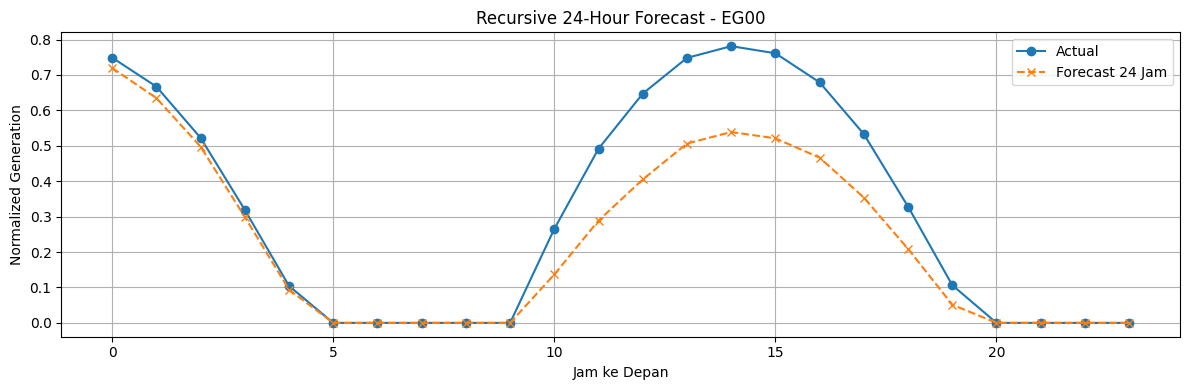

In [ ]:
def forecast_24h(model, start_data, initial_lag):
    forecasts = []
    current_lag = initial_lag

    for i in range(len(start_data)):
        row = start_data.iloc[[i]].copy()
        row['lag_1'] = current_lag
        pred = max(0, model.predict(row)[0])
        forecasts.append(pred)
        current_lag = pred

    return forecasts

X_te_eg = res_eg00['X_test']
y_te_eg = res_eg00['y_test']

predicted_24h = forecast_24h(final_model, X_te_eg.head(24), y_te_eg.iloc[0])

plt.figure(figsize=(12, 4))
plt.plot(range(24), y_te_eg.iloc[:24].values, label='Actual', marker='o')
plt.plot(range(24), predicted_24h, label='Forecast 24 Jam', linestyle='--', marker='x')
plt.title('Recursive 24-Hour Forecast - EG00')
plt.xlabel('Jam ke Depan')
plt.ylabel('Normalized Generation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Export Hasil

In [ ]:
final_df.to_csv('/content/solar_model_performance.csv', index=False)
final_df.to_excel('/content/solar_model_performance.xlsx', index=False, engine='openpyxl')

print("Hasil disimpan ke:")
print("  /content/solar_model_performance.csv")
print("  /content/solar_model_performance.xlsx")
print("\nRingkasan akhir:")
display(final_df.describe())

Hasil disimpan ke:
  /content/solar_model_performance.csv
  /content/solar_model_performance.xlsx

Ringkasan akhir:


,MSE,R2
count,179.000000,179.000000
mean,0.000741,0.985107
std,0.000382,0.010059
min,0.000047,0.951582
25%,0.000459,0.978947
50%,0.000707,0.987704
75%,0.000966,0.992544
max,0.002054,0.999483
